# DS605: Lab Assignment 2
## Vectorized Programming with NumPy and Data Wrangling with Pandas

**Name:** GAURI DAWAR  
**ID:** 202618064  
**Course:** MSc DS 605  

This notebook contains the implementation of NumPy vectorized operations and Pandas data wrangling using the Titanic dataset from Kaggle.

# Part A - Vectorized Programming with NumPy

In [3]:
import numpy as np #numerical arrays and mathematical operations
import pandas as pd #tables/DataFrames and data manipulation
import matplotlib.pyplot as plt # for customizing and displaying plots
import seaborn as sns # for statistical visualizations

## Task 1: Arrays, Statistics, and Indexing

In [5]:
np.random.seed(42)  # reproducibility - same random numbers every run
A = np.random.randint(1, 101, size=100)  # 100 random ints between 1-100

print("Array A stats:")
print("Min:", np.min(A))
print("Max:", np.max(A))
print("Median:", np.median(A))
print("Mean:", np.mean(A))
print("Std Dev:", np.std(A))

B = np.arange(0, 100)  # 100 values, step default 1

zeros = np.zeros((3,4))
ones = np.ones((3,4))
print("Zeros shape/dtype:", zeros.shape, zeros.dtype)
print("Ones shape/dtype:", ones.shape, ones.dtype)

lin = np.linspace(0, 10, 100)  # 100 evenly spaced values between 0-10

Array A stats:
Min: 2
Max: 100
Median: 54.0
Mean: 51.54
Std Dev: 29.278463074417004
Zeros shape/dtype: (3, 4) float64
Ones shape/dtype: (3, 4) float64


`np.arange(start, stop, step)` is defined by step size — number of elements is derived.
`np.linspace(start, stop, num)` is defined by number of elements — step size is derived.

In [6]:
# 2D array
arr2d = np.array([[1,2,3],[4,5,6],[7,8,9]])
print("2D shape:", arr2d.shape, "ndim:", arr2d.ndim)
print("Row 0:", arr2d[0])
print("Col 1:", arr2d[:,1])
print("Slice:", arr2d[0:2, 1:3])

# 3D array
arr3d = np.array([[[1,2],[3,4]],[[5,6],[7,8]]])
print("3D shape:", arr3d.shape, "ndim:", arr3d.ndim)

# reshape and flatten
matrix = B.reshape(10,10)
flat = matrix.flatten()

2D shape: (3, 3) ndim: 2
Row 0: [1 2 3]
Col 1: [2 5 8]
Slice: [[2 3]
 [5 6]]
3D shape: (2, 2, 2) ndim: 3


## Task 2 — Vectorized Arithmetic & Linear Algebra

In [11]:
import numpy as np

square_matrix = np.array([[4, 7], [2, 6]])
print(f"Square Matrix:\n{square_matrix}")

matrix_transpose = square_matrix.T
print(f"Transpose of Square Matrix:\n{matrix_transpose}")
matrix_determinant = int(np.linalg.det(square_matrix))

print(f"Determinant of Square Matrix: {matrix_determinant}")

if matrix_determinant != 0:
    matrix_inverse = np.linalg.inv(square_matrix)
    print(f"Inverse of Square Matrix:\n{matrix_inverse}")

    # Verify A @ A^-1 using np.allclose()
    identity_matrix = square_matrix @ matrix_inverse
    
    print(f"A @ A^-1:\n{np.round(identity_matrix, 2)}")
else:
    print("The square matrix is singular and does not have an inverse.")

Square Matrix:
[[4 7]
 [2 6]]
Transpose of Square Matrix:
[[4 2]
 [7 6]]
Determinant of Square Matrix: 10
Inverse of Square Matrix:
[[ 0.6 -0.7]
 [-0.2  0.4]]
A @ A^-1:
[[ 1. -0.]
 [ 0.  1.]]


## Task 3 - Normal Distribution and Histogram

Chosen mean=50, std=10
Sample mean=49.82, sample std=10.02


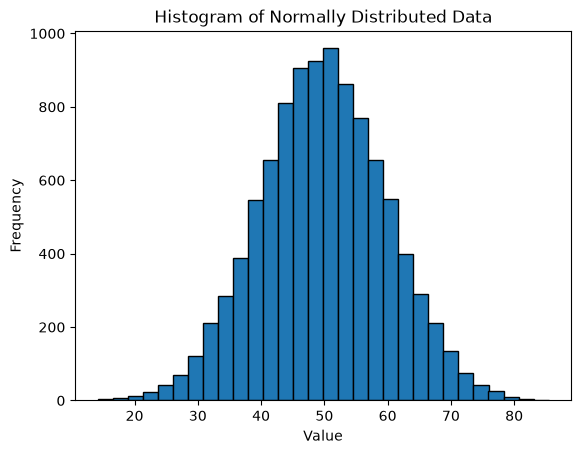

In [10]:
mu, sigma = 50, 10  # chosen mean and std dev
data = np.random.normal(mu, sigma, 10000)

sample_mean = np.mean(data)
sample_std = np.std(data)
print(f"Chosen mean={mu}, std={sigma}")
print(f"Sample mean={sample_mean:.2f}, sample std={sample_std:.2f}")

plt.hist(data, bins=30, edgecolor='black')
plt.title("Histogram of Normally Distributed Data")
plt.xlabel("Value"); plt.ylabel("Frequency")
plt.show()

# Part B - Data Wrangling with Pandas: Titanic Dataset

## Task 4: Load and Inspect Data

In [13]:
df = pd.read_csv("train.csv")

df.head()
df.tail()
print(df.shape)
print(df.columns)
df.info()
df.describe()

# loc vs iloc
print(df.loc[0, "Name"])      # label-based
print(df.iloc[0, 3])          # position-based (col index 3 = Name)

(891, 12)
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
Braund, Mr. Owen Harris
Braund, Mr. Owen Harris


## Task 5: Filtering and Querying

In [14]:
# 1. Male passengers older than 50
q1 = df[(df['Sex']=='male') & (df['Age']>50)]
print("Male >50:", len(q1))

# 2. Female first-class passengers survival %
q2 = df[(df['Sex']=='female') & (df['Pclass']==1)]
print("Female 1st class:", len(q2), "Survival %:", q2['Survived'].mean()*100)

# 3. Age 20-40, Fare above median, survived
median_fare = df['Fare'].median()
q3 = df[(df['Age']>=20)&(df['Age']<=40)&(df['Fare']>median_fare)&(df['Survived']==1)]
print("Q3:", len(q3))

# 4. Alone, age<30, did not survive
q4 = df[(df['SibSp']==0)&(df['Parch']==0)&(df['Age']<30)&(df['Survived']==0)]
print("Q4:", len(q4))

# 5. Embarked S, Pclass 2/3, Fare above Southampton median
south_median = df[df['Embarked']=='S']['Fare'].median()
q5 = df[(df['Embarked']=='S')&(df['Pclass'].isin([2,3]))&(df['Fare']>south_median)]
print("Q5:", len(q5))

Male >50: 47
Female 1st class: 94 Survival %: 96.80851063829788
Q3: 104
Q4: 141
Q5: 193


## Task 6: groupby and Aggregation

In [15]:
print(df.groupby('Sex')['Survived'].mean())
print(df.groupby('Pclass')['Survived'].mean())
print(df.groupby('Pclass')[['Age','Fare']].mean())
print(df.groupby(['Sex','Pclass']).agg(count=('Survived','size'), survival_rate=('Survived','mean')))
print(df.groupby('Embarked').agg(count=('Embarked','size'), avg_fare=('Fare','mean'), survival_rate=('Survived','mean')))

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64
              Age       Fare
Pclass                      
1       38.233441  84.154687
2       29.877630  20.662183
3       25.140620  13.675550
               count  survival_rate
Sex    Pclass                      
female 1          94       0.968085
       2          76       0.921053
       3         144       0.500000
male   1         122       0.368852
       2         108       0.157407
       3         347       0.135447
          count   avg_fare  survival_rate
Embarked                                 
C           168  59.954144       0.553571
Q            77  13.276030       0.389610
S           644  27.079812       0.336957


## Task 7: Missing Values and Fare Outliers

             count        pct
PassengerId      0   0.000000
Survived         0   0.000000
Pclass           0   0.000000
Name             0   0.000000
Sex              0   0.000000
Age            177  19.865320
SibSp            0   0.000000
Parch            0   0.000000
Ticket           0   0.000000
Fare             0   0.000000
Cabin          687  77.104377
Embarked         2   0.224467


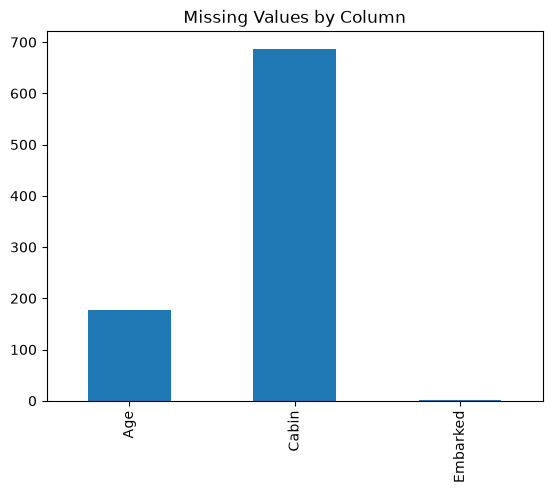

Before: 177
After: 0
Outlier count: 116


In [16]:
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum()/len(df))*100
print(pd.DataFrame({'count':missing_count,'pct':missing_pct}))

missing_count[missing_count>0].plot(kind='bar')
plt.title("Missing Values by Column")
plt.show()

print("Before:", df['Age'].isnull().sum())
df['Age_mean_filled'] = df['Age'].fillna(df['Age'].mean())
print("After:", df['Age_mean_filled'].isnull().sum())

# imputation methods (do on copies so you can compare)
df['Age_median'] = df['Age'].fillna(df['Age'].median())
df['Age_mode'] = df['Age'].fillna(df['Age'].mode()[0])
df['Age_random'] = df['Age'].apply(lambda x: np.random.choice(df['Age'].dropna()) if pd.isnull(x) else x)

# Fare outliers
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3-Q1
lower, upper = Q1-1.5*IQR, Q3+1.5*IQR
outliers = df[(df['Fare']<lower)|(df['Fare']>upper)]
print("Outlier count:", len(outliers))

## Task 8: Features and Pivot Table

In [17]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize']==1).astype(int)

pivot = df.pivot_table(index='Sex', columns='Pclass', values='Survived', aggfunc='mean')
print(pivot)
print("Highest:", pivot.stack().idxmax(), pivot.stack().max())
print("Lowest:", pivot.stack().idxmin(), pivot.stack().min())

Pclass         1         2         3
Sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447
Highest: ('female', np.int64(1)) 0.9680851063829787
Lowest: ('male', np.int64(3)) 0.13544668587896252


## Task 9: Visualizations and Observations

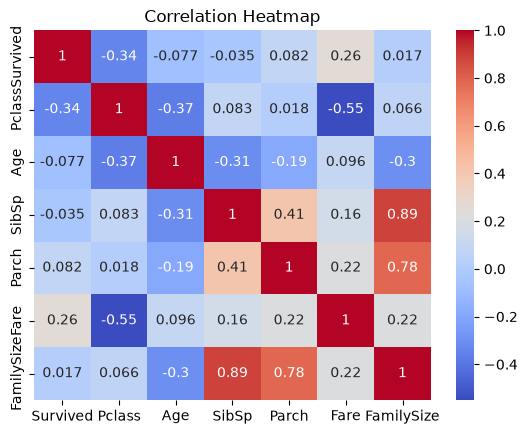

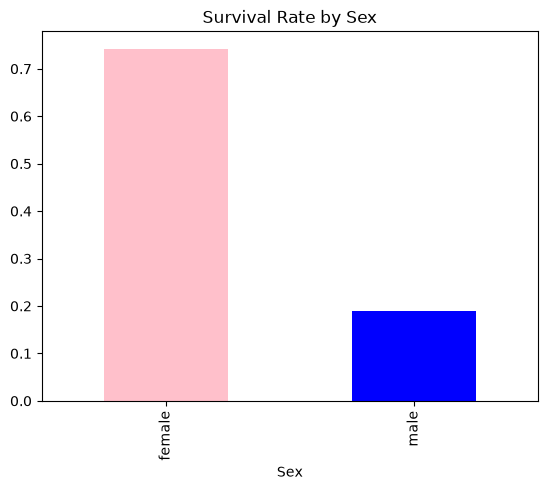

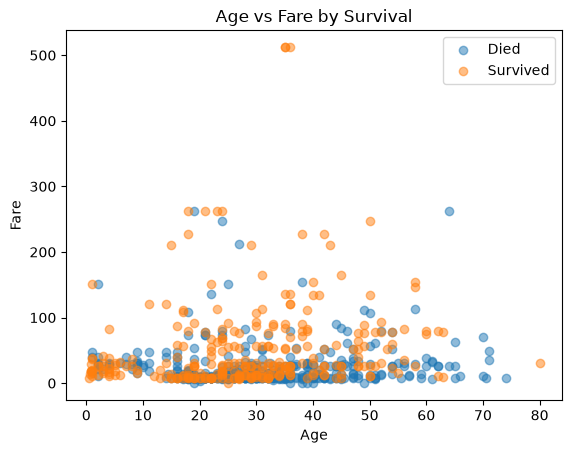

In [18]:
num_cols = df[['Survived','Pclass','Age','SibSp','Parch','Fare','FamilySize']]
corr = num_cols.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['pink','blue'])
plt.title("Survival Rate by Sex")
plt.show()

plt.scatter(df[df['Survived']==0]['Age'], df[df['Survived']==0]['Fare'], alpha=0.5, label='Died')
plt.scatter(df[df['Survived']==1]['Age'], df[df['Survived']==1]['Fare'], alpha=0.5, label='Survived')
plt.xlabel("Age"); plt.ylabel("Fare"); plt.legend()
plt.title("Age vs Fare by Survival")
plt.show()